# **Advanced Geospatial Project: Climate & Agriculture**

End-to-end pipeline using Earth Engine, weather APIs, machine learning and explainability

In [2]:
!pip install earthengine-api geemap xgboost shap requests pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.6 MB/s eta 0:00:00


## **Authentification Google Earth Engine**

In [3]:
import ee
ee.Authenticate()

In [4]:
ee.Initialize(project='gee-senegal')

In [5]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='gee-senegal')

Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [7]:
import ee
import geemap

ee.Initialize(project='gee-senegal')

Map = geemap.Map()

# Zone Sénégal
senegal = ee.FeatureCollection("FAO/GAUL/2015/level0") \
    .filter(ee.Filter.eq('ADM0_NAME', 'Senegal'))

# Sentinel-2
image = ee.ImageCollection('COPERNICUS/S2') \
    .filterBounds(senegal) \
    .filterDate('2023-01-01', '2023-12-31') \
    .median()

# NDVI
ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

Map.centerObject(senegal, 6)
Map.addLayer(ndvi, {'min': 0, 'max': 1, 'palette': ['white','green']}, 'NDVI Sénégal')
Map

Map(center=[14.356043557179225, -14.456310197758045], controls=(WidgetControl(options=['position', 'transparen…

In [8]:
import ee
ee.Authenticate()
ee.Initialize(project='gee-senegal') # Remplacez 'your-earthengine-project-id' par votre véritable ID de projet

In [9]:
# Remplacez "VOTRE_ID_PROJET_EE_ICI" par votre véritable ID de projet Earth Engine
EE_PROJECT_ID = "gee-senegal"

import ee
ee.Authenticate()
ee.Initialize(project=EE_PROJECT_ID)

In [10]:
import ee
import geemap

# Authentification (une seule fois)
ee.Authenticate()

# Initialisation avec ton projet
ee.Initialize(project='gee-senegal')

# Carte
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [11]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='gee-senegal')

Map = geemap.Map()

# Charger les pays
countries = ee.FeatureCollection("FAO/GAUL/2015/level0")

# Filtrer le Sénégal
senegal = countries.filter(ee.Filter.eq('ADM0_NAME', 'Senegal'))

# Ajouter à la carte
Map.addLayer(senegal, {}, 'Senegal')

Map.centerObject(senegal, 6)

Map

Map(center=[14.356043557179161, -14.456310197758082], controls=(WidgetControl(options=['position', 'transparen…

In [12]:
countries = ee.FeatureCollection("FAO/GAUL/2015/level0")

In [13]:
senegal = countries.filter(ee.Filter.eq('ADM0_NAME', 'Senegal'))

In [14]:
countries = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
senegal = countries.filter(ee.Filter.eq('country_na', 'Senegal'))

## **Données satellitaires pour le Sénégal (Sentinel-2)**

In [15]:
import ee
import geemap

# Auth (si nécessaire)
ee.Authenticate()

# Init avec projet
ee.Initialize(project='gee-senegal')

# Carte
Map = geemap.Map()

# Dataset correct
countries = ee.FeatureCollection("FAO/GAUL/2015/level0")

# Filtrer Sénégal
senegal = countries.filter(ee.Filter.eq('ADM0_NAME', 'Senegal'))

# Affichage
Map.addLayer(senegal, {}, 'Senegal')
Map.centerObject(senegal, 6)

Map

Map(center=[14.356043557179161, -14.456310197758082], controls=(WidgetControl(options=['position', 'transparen…

## **Données satellites (NDVI Sentinel-2)**

In [16]:

import geemap

Map = geemap.Map()

image = ee.ImageCollection('COPERNICUS/S2') \
    .filterDate('2023-01-01', '2023-12-31') \
    .median()

ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

Map.addLayer(ndvi, {'min': 0, 'max': 1, 'palette': ['white','green']}, 'NDVI')
Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

## **API météo (Open-Meteo)**

In [17]:

import requests
import pandas as pd

url = "https://api.open-meteo.com/v1/forecast?latitude=50.63&longitude=3.06&hourly=temperature_2m"
data = requests.get(url).json()

df_weather = pd.DataFrame(data['hourly'])
df_weather.head()


,time,temperature_2m
0,2026-03-22T00:00,6.0
1,2026-03-22T01:00,6.2
2,2026-03-22T02:00,5.5
3,2026-03-22T03:00,4.7
4,2026-03-22T04:00,4.3


## **Machine Learning (XGBoost)**

In [18]:

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Fake dataset for demo
import numpy as np
X = np.random.rand(100,4)
y = np.random.randint(0,2,100)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = XGBClassifier()
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Modèle
model = RandomForestClassifier()

# Entraînement
model.fit(X_train, y_train)

# 👉 PRÉDICTIONS (c’est ça qui manque chez toi)
y_pred = model.predict(X_test)

# Matrice de confusion
print(confusion_matrix(y_test, y_pred))

[[12  2]
 [ 4  2]]


In [20]:
from sklearn.metrics import confusion_matrix

# Prédictions
y_pred = model.predict(X_test)

# Matrice de confusion
print(confusion_matrix(y_test, y_pred))

[[12  2]
 [ 4  2]]


In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import numpy as np

# Fake dataset
X = np.random.rand(100,4)
y = np.random.randint(0,2,100)

# Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

# Modèle
model = XGBClassifier()
model.fit(X_train, y_train)

# 👉 Étape manquante
y_pred = model.predict(X_test)

# Résultat
print(confusion_matrix(y_test, y_pred))

[[3 5]
 [6 6]]


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.38      0.35         8
           1       0.55      0.50      0.52        12

    accuracy                           0.45        20
   macro avg       0.44      0.44      0.44        20
weighted avg       0.46      0.45      0.45        20



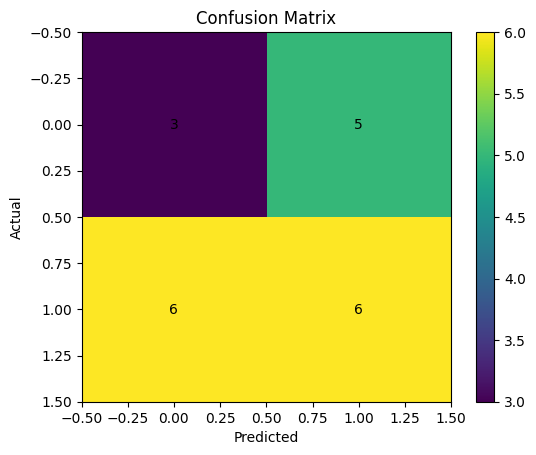

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcul matrice
cm = confusion_matrix(y_test, y_pred)

# Affichage
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# Axes
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Valeurs dans les cases
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

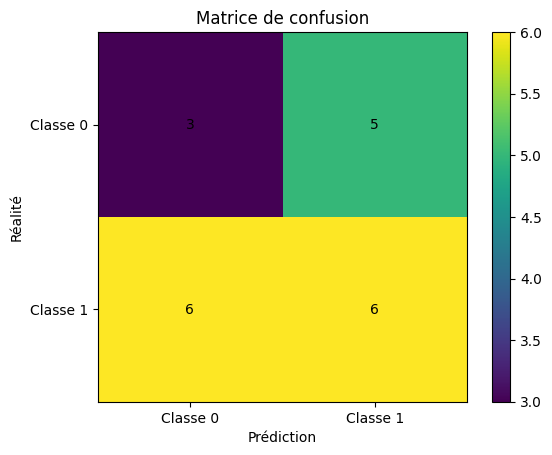

In [24]:
plt.figure()
plt.imshow(cm)

plt.xticks([0,1], ["Classe 0", "Classe 1"])
plt.yticks([0,1], ["Classe 0", "Classe 1"])

plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

**heatmap normalized**

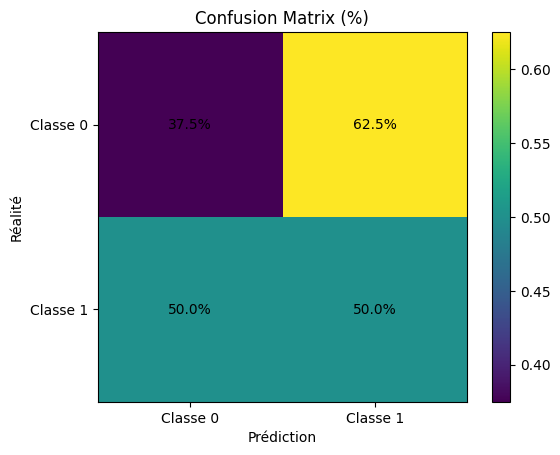

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Normalisation (par ligne)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
plt.imshow(cm_norm)

plt.title("Confusion Matrix (%)")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")

plt.xticks([0,1], ["Classe 0", "Classe 1"])
plt.yticks([0,1], ["Classe 0", "Classe 1"])

# Affichage en %
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]*100:.1f}%", ha="center", va="center")

plt.colorbar()
plt.show()

**Searbon**

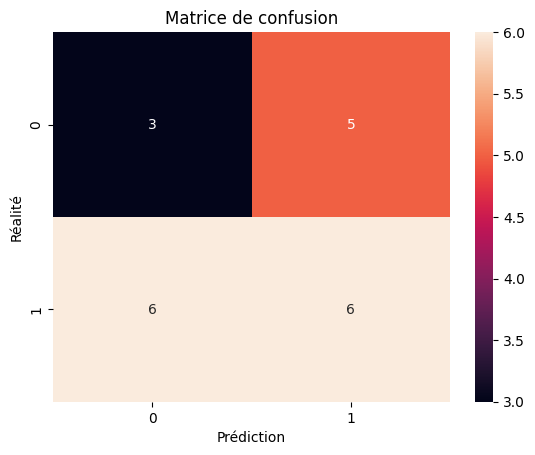

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cbar=True)

plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion")

plt.show()

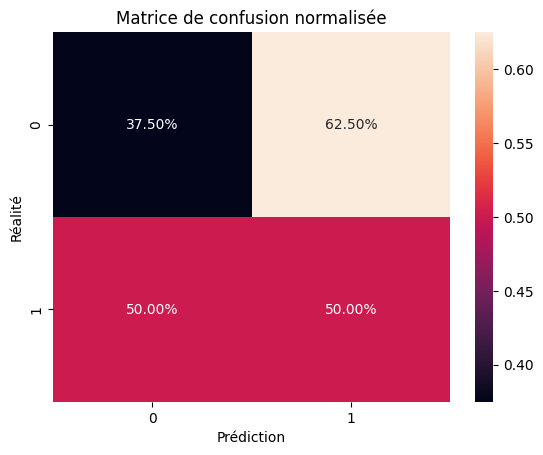

In [27]:
#searbon normalized
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
sns.heatmap(cm_norm, annot=True, fmt=".2%", cbar=True)

plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion normalisée")

plt.show()

In [28]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[3 5]
 [6 6]]


## **Explainability with SHAP**

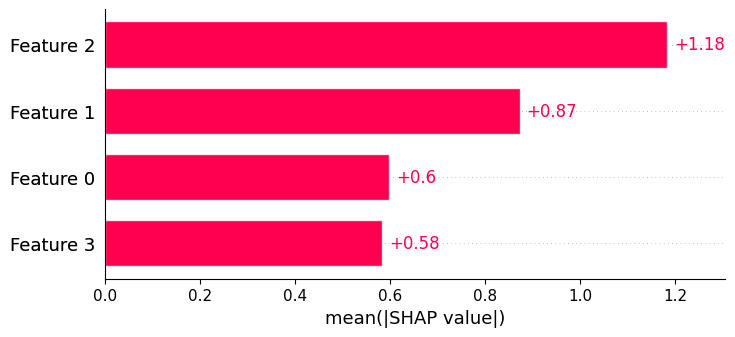

In [29]:

import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)


**ROC + AUC**

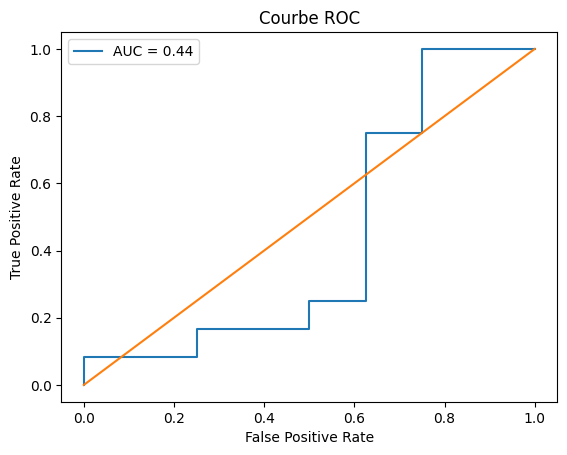

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilités (IMPORTANT pour ROC)
y_proba = model.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1])  # ligne aléatoire

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()

plt.show()

**XGBoost**

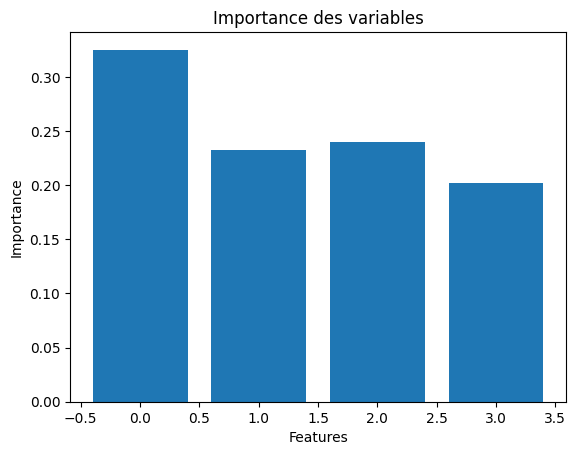

In [31]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)

plt.title("Significance of variables")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

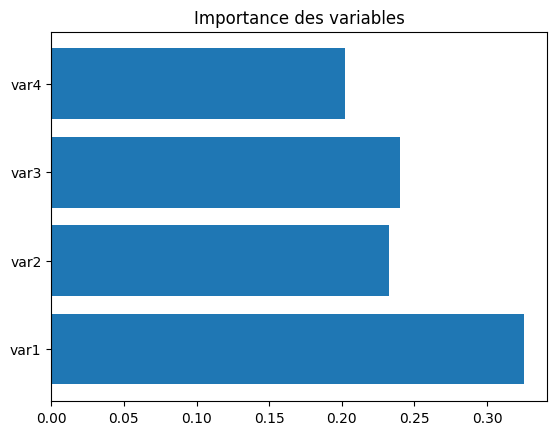

In [32]:
feature_names = ["var1", "var2", "var3", "var4"]

plt.figure()
plt.barh(feature_names, importances)
plt.title("Importance des variables")
plt.show()

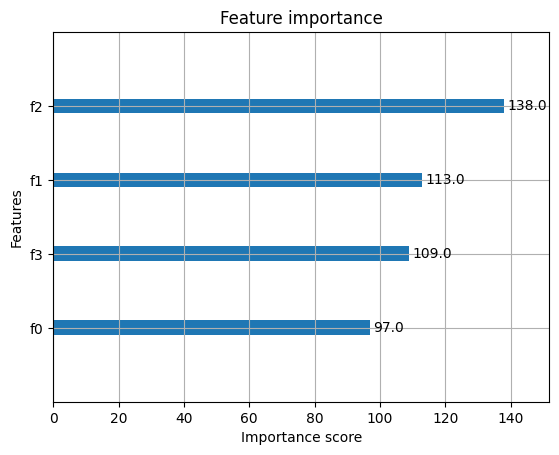

In [33]:
from xgboost import plot_importance

plot_importance(model)
plt.show()

**Modal Optimization (GridSearch)**

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [35]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

**RandomizedSearch**

In [36]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3,5,7,10],
    'n_estimators': [50,100,200,300],
    'learning_rate': [0.01,0.05,0.1,0.2],
    'subsample': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    XGBClassifier(),
    param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)

Best params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1}


**End-to-end pipeline: Online data import + Machine Learning**

In [37]:
!pip install pandas numpy scikit-learn requests matplotlib

In [38]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

**Data Import** (CSV)

In [39]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Data exploration**

In [40]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.50000

**Data preparation**

In [41]:
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Machine Learning modal **

In [42]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**Evaluation**

In [43]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Visualization**

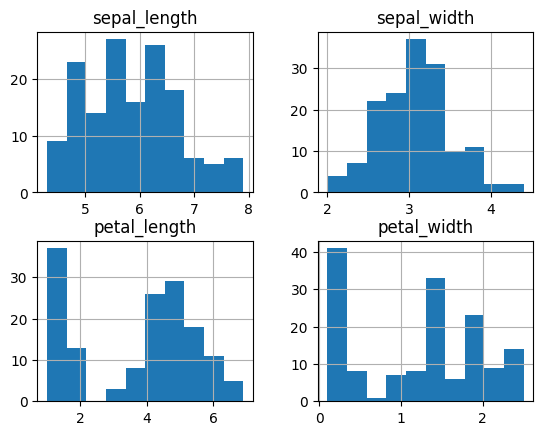

In [44]:
df.hist()
plt.show()